# jiRAG — Jira Retrieval-Augmented Generation Assistant

This notebook serves as the primary entry point for the **jiRAG** project. It manages the end-to-end workflow, including:
*   **Dataset Loading & Validation**: Loading, validating, documenting, and versioning the approved 1,000-ticket dataset.
*   **Preprocessing**: Text cleaning and chunking strategies.
*   **RAG & Vector Storage**: Document indexing and retrieval logic.
*   **Evaluation**: RAGAS and custom metrics for system performance.
*   **Model Fine-tuning**: QLoRA-based adaptation of LLMs.
*   **Agent & Jira Sync**: Tool-use for real-time synchronization with Jira.
*   **Deployment**: A final demo interface for support interaction.

## 0. Environment and Reproducibility

We begin by installing basic dependencies and setting up the software environment.

In [6]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn


In [7]:
import os
import json
import random
import hashlib
import platform
import sys
import csv
import re
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import sklearn

# --- 1. Global Configuration ---
CONFIG = {
    "project_name": "jiRAG",
    "project_version": "0.1.0",
    "random_seed": 42,

    "dataset_version": "final_1000_v1",
    "dataset_filename": "jira_rag_master_FINAL_1000.csv",
    "target_clean_tickets": 1000,

    "prompt_version": "v1",
    "split_version": "v1_seed42",
    "index_version": "v1",
    "model_version": "base",

    "train_ratio": 0.75,
    "validation_ratio": 0.15,
    "test_ratio": 0.10,

    # These names refer to the normalized internal DataFrame schema,
    # not to the original repeated Jira Labels headers.
    "stratification_columns": ["family", "solution_type"],

    "default_chunking_strategy": "one_ticket_one_document"
}

SEED_INITIALIZED = False

### Reproducibility Settings

We define `set_global_seed` to ensure results are as consistent as possible across runs. Note that while these settings cover CPU and GPU operations, exact floating-point bitwise reproducibility on GPUs is not always guaranteed due to non-deterministic atomic operations in certain CUDA kernels.

In [8]:
def set_global_seed(seed):
    global SEED_INITIALIZED
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Enforce deterministic algorithms where possible
    torch.use_deterministic_algorithms(True, warn_only=True)
    SEED_INITIALIZED = True
    print(f"[INFO] Global seed set to: {seed}")

set_global_seed(CONFIG["random_seed"])

[INFO] Global seed set to: 42


### Directory Structure and Google Drive Mounting

We organize the project into a strict folder hierarchy stored on Google Drive to ensure persistence.

**Storage Strategy:**
*   **GitHub**: Stores code, notebooks, configuration, manifests, and documentation.
*   **Google Drive**: Stores datasets, deterministic splits, Vector DB files, checkpoints, trained adapters, logs, and generated artifacts.
*   **Colab Local Storage**: Temporary/volatile; must not be used for persistent data.
*   **Security**: Secrets and credentials must never be stored in the notebook, project files, or Git.

In [9]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/jiRAG")

# Define internal structure
PATHS = {
    "root": PROJECT_ROOT,
    "data_seeds": PROJECT_ROOT / "data" / "seeds",
    "data_raw": PROJECT_ROOT / "data" / "raw",
    "data_processed": PROJECT_ROOT / "data" / "processed",
    "data_splits": PROJECT_ROOT / "data" / "splits",
    "data_eval": PROJECT_ROOT / "data" / "evaluation",
    "data_manifests": PROJECT_ROOT / "data" / "manifests",
    "vector_store": PROJECT_ROOT / "vector_store",
    "models": PROJECT_ROOT / "models",
    "checkpoints": PROJECT_ROOT / "checkpoints",
    "reports_qa": PROJECT_ROOT / "reports" / "data_qa",
    "reports_eval": PROJECT_ROOT / "reports" / "evaluation",
    "reports_figs": PROJECT_ROOT / "reports" / "figures",
    "logs": PROJECT_ROOT / "logs",
    "exports": PROJECT_ROOT / "exports"
}

# Create directories safely
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

print(f"[INFO] Project structure initialized at: {PROJECT_ROOT}")

Mounted at /content/drive
[INFO] Project structure initialized at: /content/drive/MyDrive/jiRAG


### Environment Inspection

Summary of the current runtime environment and project state.

In [10]:
def inspect_environment():
    is_colab = 'google.colab' in sys.modules

    print("="*50)
    print(f"Python Version:      {sys.version.split()[0]}")
    print(f"Pandas Version:      {pd.__version__}")
    print(f"NumPy Version:       {np.__version__}")
    print(f"Scikit-Learn Version: {sklearn.__version__}")
    print(f"PyTorch Version:     {torch.__version__}")
    print(f"CUDA Available:      {torch.cuda.is_available()}")
    print("-"*50)
    print(f"Running in Colab:    {is_colab}")
    print(f"Working Directory:   {os.getcwd()}")
    print(f"Project Root:        {PROJECT_ROOT}")
    print(f"Random Seed:         {CONFIG['random_seed']}")
    print(f"Dataset Version:     {CONFIG['dataset_version']}")
    print("="*50)

inspect_environment()

Python Version:      3.13.15
Pandas Version:      2.2.3
NumPy Version:       2.1.3
Scikit-Learn Version: 1.6.1
PyTorch Version:     2.11.0+cpu
CUDA Available:      False
--------------------------------------------------
Running in Colab:    True
Working Directory:   /content
Project Root:        /content/drive/MyDrive/jiRAG
Random Seed:         42
Dataset Version:     final_1000_v1


### Config Management

Saving the configuration to the manifests folder and checking for existing versions to prevent accidental drift.

In [11]:
config_file = PATHS["data_manifests"] / f"project_config_{CONFIG['dataset_version']}.json"

def sync_config(config, file_path):
    if file_path.exists():
        with open(file_path, 'r', encoding='utf-8') as f:
            existing_config = json.load(f)

        # Compare existing values (timestamps are handled in run metadata, not CONFIG)
        if config == existing_config:
            print(f"[INFO] Configuration matches existing file: {file_path.name}")
        else:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            backup_path = file_path.with_suffix(f".bak_{timestamp}.json")
            file_path.rename(backup_path)
            print(f"[WARN] Config mismatch. Backup created at {backup_path.name}. Updating file...")
            with open(file_path, 'w', encoding='utf-8') as f:
                json.dump(config, f, indent=2, ensure_ascii=False)
    else:
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump(config, f, indent=2, ensure_ascii=False)
        print(f"[INFO] Configuration created: {file_path.name}")

sync_config(CONFIG, config_file)

[INFO] Configuration matches existing file: project_config_final_1000_v1.json


### Utility Functions

Helper functions for data integrity and experiment tracking.

In [12]:
def calculate_sha256(file_path):
    sha256_hash = hashlib.sha256()
    with open(file_path, "rb") as f:
        for byte_block in iter(lambda: f.read(4096), b""):
            sha256_hash.update(byte_block)
    return sha256_hash.hexdigest()

def save_run_metadata(stage_name, extra_metadata=None):
    metadata = {
        "stage_name": stage_name,
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "project_version": CONFIG["project_version"],
        "dataset_version": CONFIG["dataset_version"],
        "dataset_filename": CONFIG["dataset_filename"],
        "prompt_version": CONFIG["prompt_version"],
        "split_version": CONFIG["split_version"],
        "index_version": CONFIG["index_version"],
        "model_version": CONFIG["model_version"],
        "random_seed": CONFIG["random_seed"],
        "ratios": {
            "train": CONFIG["train_ratio"],
            "validation": CONFIG["validation_ratio"],
            "test": CONFIG["test_ratio"]
        },
        "stratification_columns": CONFIG["stratification_columns"],
        "chunking_strategy": CONFIG["default_chunking_strategy"],
        "environment": {
            "python_version": platform.python_version(),
            "pandas_version": pd.__version__,
            "numpy_version": np.__version__,
            "sklearn_version": sklearn.__version__,
            "torch_version": torch.__version__,
            "cuda_available": bool(torch.cuda.is_available())
        },
        "extra": extra_metadata or {}
    }

    log_filename = f"run_{stage_name}_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}.json"
    log_path = PATHS["logs"] / log_filename

    with open(log_path, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)
    print(f"[INFO] Metadata logged to {log_filename}")

save_run_metadata("project_bootstrap")

[INFO] Metadata logged to run_project_bootstrap_20260830_135057.json


### Bootstrap Validation

In [13]:
def validate_bootstrap():
    errors = []
    if not SEED_INITIALIZED:
        errors.append("SEED_INITIALIZED is False. Call set_global_seed() first.")

    for name, p in PATHS.items():
        if not p.exists():
            errors.append(f"Directory missing: {name} at {p}")

    total_ratio = CONFIG["train_ratio"] + CONFIG["validation_ratio"] + CONFIG["test_ratio"]
    if abs(total_ratio - 1.0) > 1e-9:
        errors.append(f"Split ratios do not equal 1.0 (Sum: {total_ratio})")

    # Strict ratio checks
    if CONFIG["train_ratio"] != 0.75: errors.append("train_ratio must be 0.75")
    if CONFIG["validation_ratio"] != 0.15: errors.append("validation_ratio must be 0.15")
    if CONFIG["test_ratio"] != 0.10: errors.append("test_ratio must be 0.10")

    # Value checks
    if CONFIG["target_clean_tickets"] != 1000: errors.append("target_clean_tickets must be 1000")
    if CONFIG["dataset_filename"] != "jira_rag_master_FINAL_1000.csv":
        errors.append("Incorrect dataset_filename")
    if CONFIG["dataset_version"] != "final_1000_v1":
        errors.append("Incorrect dataset_version")
    if CONFIG["stratification_columns"] != ["family", "solution_type"]:
        errors.append("Incorrect stratification_columns")
    if CONFIG["default_chunking_strategy"] != "one_ticket_one_document":
        errors.append("Incorrect default_chunking_strategy")

    if not config_file.exists():
        errors.append("Project config file was not created.")

    if errors:
        print("\u274c jiRAG Bootstrap Validation Failed:")
        for err in errors:
            print(f"  - {err}")
        raise RuntimeError("Stage 0 validation failed. Cannot proceed with invalid environment/config.")
    else:
        print("\u2705 jiRAG Stage 0 completed: environment and reproducibility are ready")

validate_bootstrap()

✅ jiRAG Stage 0 completed: environment and reproducibility are ready


### Bootstrap Summary

Stage 0 has successfully initialized the persistent project structure, fixed the experiment seed and configuration, and recorded the runtime environment metadata.

Stage 0 validates the environment and reproducibility infrastructure only. It does not load, validate, or process the final dataset.

## 1. Final Dataset Loading and Validation

This stage will load and validate the approved final dataset:

`/content/drive/MyDrive/jiRAG/data/raw/jira_rag_master_FINAL_1000.csv`

The stage will verify the raw Jira-compatible CSV structure, normalize the three repeated `Labels` columns only inside the working DataFrame, calculate dataset fingerprints, perform Data Quality checks, and create a versioned manifest.

The raw CSV file will remain unchanged.

### Introduction to Dataset Validation

In this stage, we transition from the project environment to the data layer. We load the approved 1,000-ticket dataset and subject it to rigorous verification.

**Validation Protocol:**
*   **Schema Normalization**: The raw Jira CSV contains repeated `Labels` headers. We map these to `ticket_id`, `family`, and `solution_type` in memory for easier processing.
*   **Jira Compatibility**: The raw CSV file on Google Drive remains untouched and fully compatible with Jira imports.
*   **Integrity Gates**: We enforce specific row counts, unique constraints, word count boundaries, and Jira workflow consistency.
*   **Privacy & Security**: Automated scans for emails and credential assignments ensure the dataset is safe for RAG evaluation.
*   **Reproducibility**: We calculate both a raw SHA-256 and a canonical content fingerprint to ensure data consistency across different execution environments.

*Note: Any structural or logic failure will halt the pipeline immediately to prevent downstream errors.*

In [14]:
# 1. Define Paths and Constants
RAW_DATASET_PATH = PATHS["data_raw"] / CONFIG["dataset_filename"]
PROCESSED_DATASET_PATH = PATHS["data_processed"] / "tickets_clean_v1.csv"
DATASET_MANIFEST_PATH = PATHS["data_manifests"] / "dataset_manifest_final_1000_v1.json"
DATA_QA_REPORT_PATH = PATHS["reports_qa"] / "dataset_qa_final_1000_v1.json"

EXPECTED_RAW_HEADER = [
    "Summary", "Description", "Work Type", "Priority",
    "Status", "Component", "Labels", "Labels", "Labels"
]

EXPECTED_NORMALIZED_COLUMNS = [
    "Summary", "Description", "Work Type", "Priority",
    "Status", "Component", "ticket_id", "family", "solution_type"
]

ALLOWED_WORK_TYPES = {"Bug", "Task", "Story"}
ALLOWED_PRIORITIES = {"Highest", "High", "Medium", "Low"}
ALLOWED_STATUSES = {"To Do", "In Progress", "Done"}
EXPECTED_FAMILIES = {
    "family-salesforce-flow", "family-crm-integration", "family-salesforce-security",
    "family-soql-analytics", "family-email-activity", "family-crm-record-management",
    "family-revenue-operations", "family-api-platform", "family-ai-to-soql", "family-data-migration"
}
EXPECTED_SOLUTION_TYPES = {
    "solution-verified", "solution-partial", "solution-workaround", "solution-unresolved"
}

REQUIRED_DESC_HEADINGS = [
    "CONTEXT", "ISSUE OR REQUEST", "EXPECTED BEHAVIOR",
    "ACTUAL BEHAVIOR", "INVESTIGATION AND FINDINGS",
    "RESOLUTION", "VALIDATION"
]

# 2. Verify Physical File
if not RAW_DATASET_PATH.exists():
    print(f"[ERROR] Expected raw dataset missing at: {RAW_DATASET_PATH}")
else:
    print(f"[INFO] Found raw dataset: {RAW_DATASET_PATH.name}")

[INFO] Found raw dataset: jira_rag_master_FINAL_1000.csv


In [15]:
# 3. Raw Structure Validation (Python csv module)
print(f"[INFO] Inspecting raw structure: {RAW_DATASET_PATH.name}")

with open(RAW_DATASET_PATH, mode='r', encoding='utf-8-sig', newline='') as f:
    reader = csv.reader(f)
    raw_rows = list(reader)

raw_header = raw_rows[0]
raw_data = raw_rows[1:]

struct_errors = []
if len(raw_header) != 9:
    struct_errors.append(f"Expected 9 columns, found {len(raw_header)}")
if raw_header != EXPECTED_RAW_HEADER:
    struct_errors.append("Raw header does not match Jira-compatible standard")
if len(raw_data) != 1000:
    struct_errors.append(f"Expected 1000 data rows, found {len(raw_data)}")

for i, row in enumerate(raw_data, 1):
    if len(row) != 9:
        struct_errors.append(f"Row {i} contains {len(row)} fields instead of 9")
    if not any(field.strip() for field in row):
        struct_errors.append(f"Row {i} is completely empty")

if struct_errors:
    print("\u274c Raw Structure Validation Failed:")
    for err in struct_errors[:10]: print(f"  - {err}")
    raise RuntimeError("Raw CSV structure is invalid.")

[INFO] Inspecting raw structure: jira_rag_master_FINAL_1000.csv


In [16]:
# 4. Load, Normalize, and Fingerprint
raw_df = pd.read_csv(RAW_DATASET_PATH, encoding="utf-8-sig")
rename_map = {"Labels": "ticket_id", "Labels.1": "family", "Labels.2": "solution_type"}
tickets_df = raw_df.rename(columns=rename_map).copy()

def calculate_canonical_sha256(df):
    """Calculates a fingerprint stable across line-ending styles."""
    # Reconstruct rows exactly as they appear in a standard CSV
    rows = [list(df.columns)] + df.values.tolist()
    canonical_rows = []
    for row in rows:
        canonical_rows.append([str(f).replace('\r\n', '\n').replace('\r', '\n') for f in row])

    serialized = json.dumps(canonical_rows, ensure_ascii=False, separators=(",", ":"))
    return hashlib.sha256(serialized.encode('utf-8')).hexdigest()

raw_sha256 = calculate_sha256(RAW_DATASET_PATH)
canonical_sha256 = calculate_canonical_sha256(tickets_df)

In [17]:
# 5. Deep Data Quality Validation
validation_errors = []
validation_warnings = []

# Dataset-level checks
if tickets_df.shape != (1000, 9): validation_errors.append("DataFrame shape mismatch")
if list(tickets_df.columns) != EXPECTED_NORMALIZED_COLUMNS: validation_errors.append("Column order mismatch")
if tickets_df.isna().any().any(): validation_errors.append("Dataset contains missing values")

# Category Set Validation
if set(tickets_df['Work Type'].unique()) != ALLOWED_WORK_TYPES: validation_errors.append(f"Work Type set mismatch. Found: {tickets_df['Work Type'].unique()}")
if set(tickets_df['Priority'].unique()) != ALLOWED_PRIORITIES: validation_errors.append(f"Priority set mismatch. Found: {tickets_df['Priority'].unique()}")
if set(tickets_df['Status'].unique()) != ALLOWED_STATUSES: validation_errors.append(f"Status set mismatch. Found: {tickets_df['Status'].unique()}")
if set(tickets_df['solution_type'].unique()) != EXPECTED_SOLUTION_TYPES: validation_errors.append(f"solution_type set mismatch. Found: {tickets_df['solution_type'].unique()}")

# Whitespace check
for col in tickets_df.columns:
    if tickets_df[col].apply(lambda x: str(x).strip() == "").any():
        validation_errors.append(f"Column '{col}' contains whitespace-only values")

# Uniqueness
if not tickets_df['ticket_id'].is_unique: validation_errors.append("Duplicate ticket_id detected")
if not tickets_df['Summary'].is_unique: validation_errors.append("Duplicate Summary detected")
if not tickets_df['Description'].is_unique: validation_errors.append("Duplicate Description detected")

# ID Format and Sequence
ticket_ids = tickets_df['ticket_id'].tolist()
expected_ids = [f"tckt-{i:04d}" for i in range(1, 1001)]
if ticket_ids != expected_ids: validation_errors.append("Ticket IDs are not strictly sequential tckt-0001 to tckt-1000")

# Category Distributions
fam_counts = tickets_df['family'].value_counts().to_dict()
sol_counts = tickets_df['solution_type'].value_counts().to_dict()

if set(fam_counts.keys()) != EXPECTED_FAMILIES: validation_errors.append("Family set mismatch")
for fam, count in fam_counts.items():
    if count != 100: validation_errors.append(f"Family {fam} has {count} tickets (expected 100)")

expected_sol_dist = {"solution-verified": 550, "solution-partial": 150, "solution-workaround": 150, "solution-unresolved": 150}
for sol, count in sol_counts.items():
    if count != expected_sol_dist.get(sol): validation_errors.append(f"Solution {sol} distribution mismatch: {count}")

# Row-level scanning
for idx, row in tickets_df.iterrows():
    t_id = row['ticket_id']
    desc = str(row['Description'])
    summ = str(row['Summary'])

    # Workflow
    sol, stat = row['solution_type'], row['Status']
    if sol == 'solution-verified' and stat != "Done":
        validation_errors.append(f"{t_id}: Verified ticket must be Done")
    if sol == 'solution-unresolved' and stat not in ["To Do", "In Progress"]:
        validation_errors.append(f"{t_id}: Unresolved ticket cannot be Done")

    # Headings and Word Count
    found_headings = []
    for h in REQUIRED_DESC_HEADINGS:
        matches = list(re.finditer(rf"^{re.escape(h)}\s*$", desc, re.MULTILINE))
        if len(matches) == 1: found_headings.append((matches[0].start(), h))
        else: validation_errors.append(f"{t_id}: Heading '{h}' missing or not standalone")

    if len(found_headings) == len(REQUIRED_DESC_HEADINGS):
        sorted_headings = sorted(found_headings)
        if [h[1] for h in sorted_headings] != REQUIRED_DESC_HEADINGS:
            validation_errors.append(f"{t_id}: Description headings in wrong order")

    w_count = len(desc.split())
    if not (90 <= w_count <= 220):
        validation_errors.append(f"{t_id}: Description word count {w_count} outside 90-220 range")

    # Privacy
    combined = summ + " " + desc
    if re.search(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}", combined):
        validation_errors.append(f"{t_id}: Email address detected")
    if re.search(r"(?i)(password|token|secret|api_key)\s*[=:]\s*[^\s]{4,}", combined):
        validation_errors.append(f"{t_id}: Credential assignment detected")
    if re.search(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", combined):
        validation_warnings.append(f"{t_id}: IPv4-like pattern found (Review requested)")

In [18]:
# 6. Reporting and Persistence
print("="*60)
print(f"Dataset:      {RAW_DATASET_PATH.name}")
print(f"Raw Shape:    {raw_rows[0]} ... (1000 rows)")
print(f"Normalized:   {tickets_df.shape}")
print(f"ID Range:     {tickets_df['ticket_id'].iloc[0]} to {tickets_df['ticket_id'].iloc[-1]}")
print(f"Unique Count: {tickets_df['ticket_id'].nunique()} IDs, {tickets_df['Summary'].nunique()} Summaries")
print(f"Errors:       {len(validation_errors)}")
print(f"Warnings:     {len(validation_warnings)}")
print(f"Raw SHA-256:  {raw_sha256}")
print(f"Canon SHA-256: {canonical_sha256}")
print("="*60)

display(tickets_df.drop(columns=['Description']).head(3))

if validation_errors:
    print("\u274c Validation Errors Found:")
    display(pd.DataFrame(validation_errors, columns=["Error Message"]))
    raise RuntimeError("Stage 1 validation failed.")

# Save Artifacts
tickets_df.to_csv(PROCESSED_DATASET_PATH, index=False, encoding='utf-8')

qa_report = {
    "dataset_version": CONFIG["dataset_version"], "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "result": "passed", "counts": {"rows": 1000, "cols": 9}, "errors": [], "warnings": validation_warnings,
    "fingerprints": {"raw_sha256": raw_sha256, "canonical_sha256": canonical_sha256},
    "rule_version": "1.1"
}
with open(DATA_QA_REPORT_PATH, 'w', encoding='utf-8') as f: json.dump(qa_report, f, indent=2, ensure_ascii=False)

manifest = {
    "dataset_role": "final_approved_dataset", "dataset_version": CONFIG["dataset_version"],
    "source": str(RAW_DATASET_PATH), "processed": str(PROCESSED_DATASET_PATH),
    "row_count": 1000, "fingerprints": {"raw_sha256": raw_sha256, "canonical_sha256": canonical_sha256},
    "required_headings": REQUIRED_DESC_HEADINGS, "validation_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "validation_rule_version": "1.1"
}
with open(DATASET_MANIFEST_PATH, 'w', encoding='utf-8') as f: json.dump(manifest, f, indent=2, ensure_ascii=False)

save_run_metadata("final_dataset_validation", {
    "raw_dataset_path": str(RAW_DATASET_PATH), "processed_dataset_path": str(PROCESSED_DATASET_PATH),
    "raw_sha256": raw_sha256, "canonical_sha256": canonical_sha256, "rows": 1000, "validation_result": "passed"
})

print("\u2705 jiRAG Stage 1 completed: final dataset validated and versioned")

Dataset:      jira_rag_master_FINAL_1000.csv
Raw Shape:    ['Summary', 'Description', 'Work Type', 'Priority', 'Status', 'Component', 'Labels', 'Labels', 'Labels'] ... (1000 rows)
Normalized:   (1000, 9)
ID Range:     tckt-0001 to tckt-1000
Unique Count: 1000 IDs, 1000 Summaries
Errors:       0
Warnings:     0
Raw SHA-256:  799eb22dd89ceef1700b4972b403a97ffe6a3e945c0d22db3500675450d15fda
Canon SHA-256: eab7eb446a05d750fb86b9b6d74646bdb43fec88e1e76c1e00c75146232b9236


,Summary,Work Type,Priority,Status,Component,ticket_id,family,solution_type
0,Latest email engagement is not classified corr...,Story,Medium,Done,Salesforce Email Automation,tckt-0001,family-email-activity,solution-verified
1,Hebrew natural-language questions generate inc...,Task,Medium,In Progress,Natural Language to SOQL,tckt-0002,family-ai-to-soql,solution-partial
2,Credits and contract conversions need a tracea...,Task,Medium,In Progress,Opportunity Credits and Conversions,tckt-0003,family-revenue-operations,solution-partial


[INFO] Metadata logged to run_final_dataset_validation_20260830_135103.json
✅ jiRAG Stage 1 completed: final dataset validated and versioned


### Stage 1 Summary

*   **Load Success**: The final 1,000-ticket dataset was loaded from Google Drive.
*   **Jira Preservation**: The raw CSV remains compatible with Jira imports; normalization occurred only in the working DataFrame.
*   **Integrity**: Data Quality, privacy (PII), and workflow consistency checks passed with zero errors.
*   **Fingerprints**: Raw and canonical SHA-256 fingerprints are recorded to guarantee experiment reproducibility.
*   **Artifacts**: The processed dataset, versioned manifest, and QA report have been persisted to Drive.

Next, we will proceed to **Exploratory Data Analysis** to understand the content distribution and ticket characteristics in detail.


## 2. Exploratory Data Analysis

This stage describes the validated dataset before splitting or retrieval. The analysis uses a separate `eda_df` copy so the normalized `tickets_df` schema remains unchanged.



### 2.1 Dataset Overview and Categorical Distributions

We inspect the major ticket categories and save a compact, reproducible visualization. Display labels are shortened only inside the plots; the stored values remain unchanged.


--- Dataset Overview ---


,tickets,families,solution_types,unique_components,unique_summaries,unique_descriptions,minimum_ticket_id,maximum_ticket_id
0,1000,10,4,998,1000,1000,tckt-0001,tckt-1000


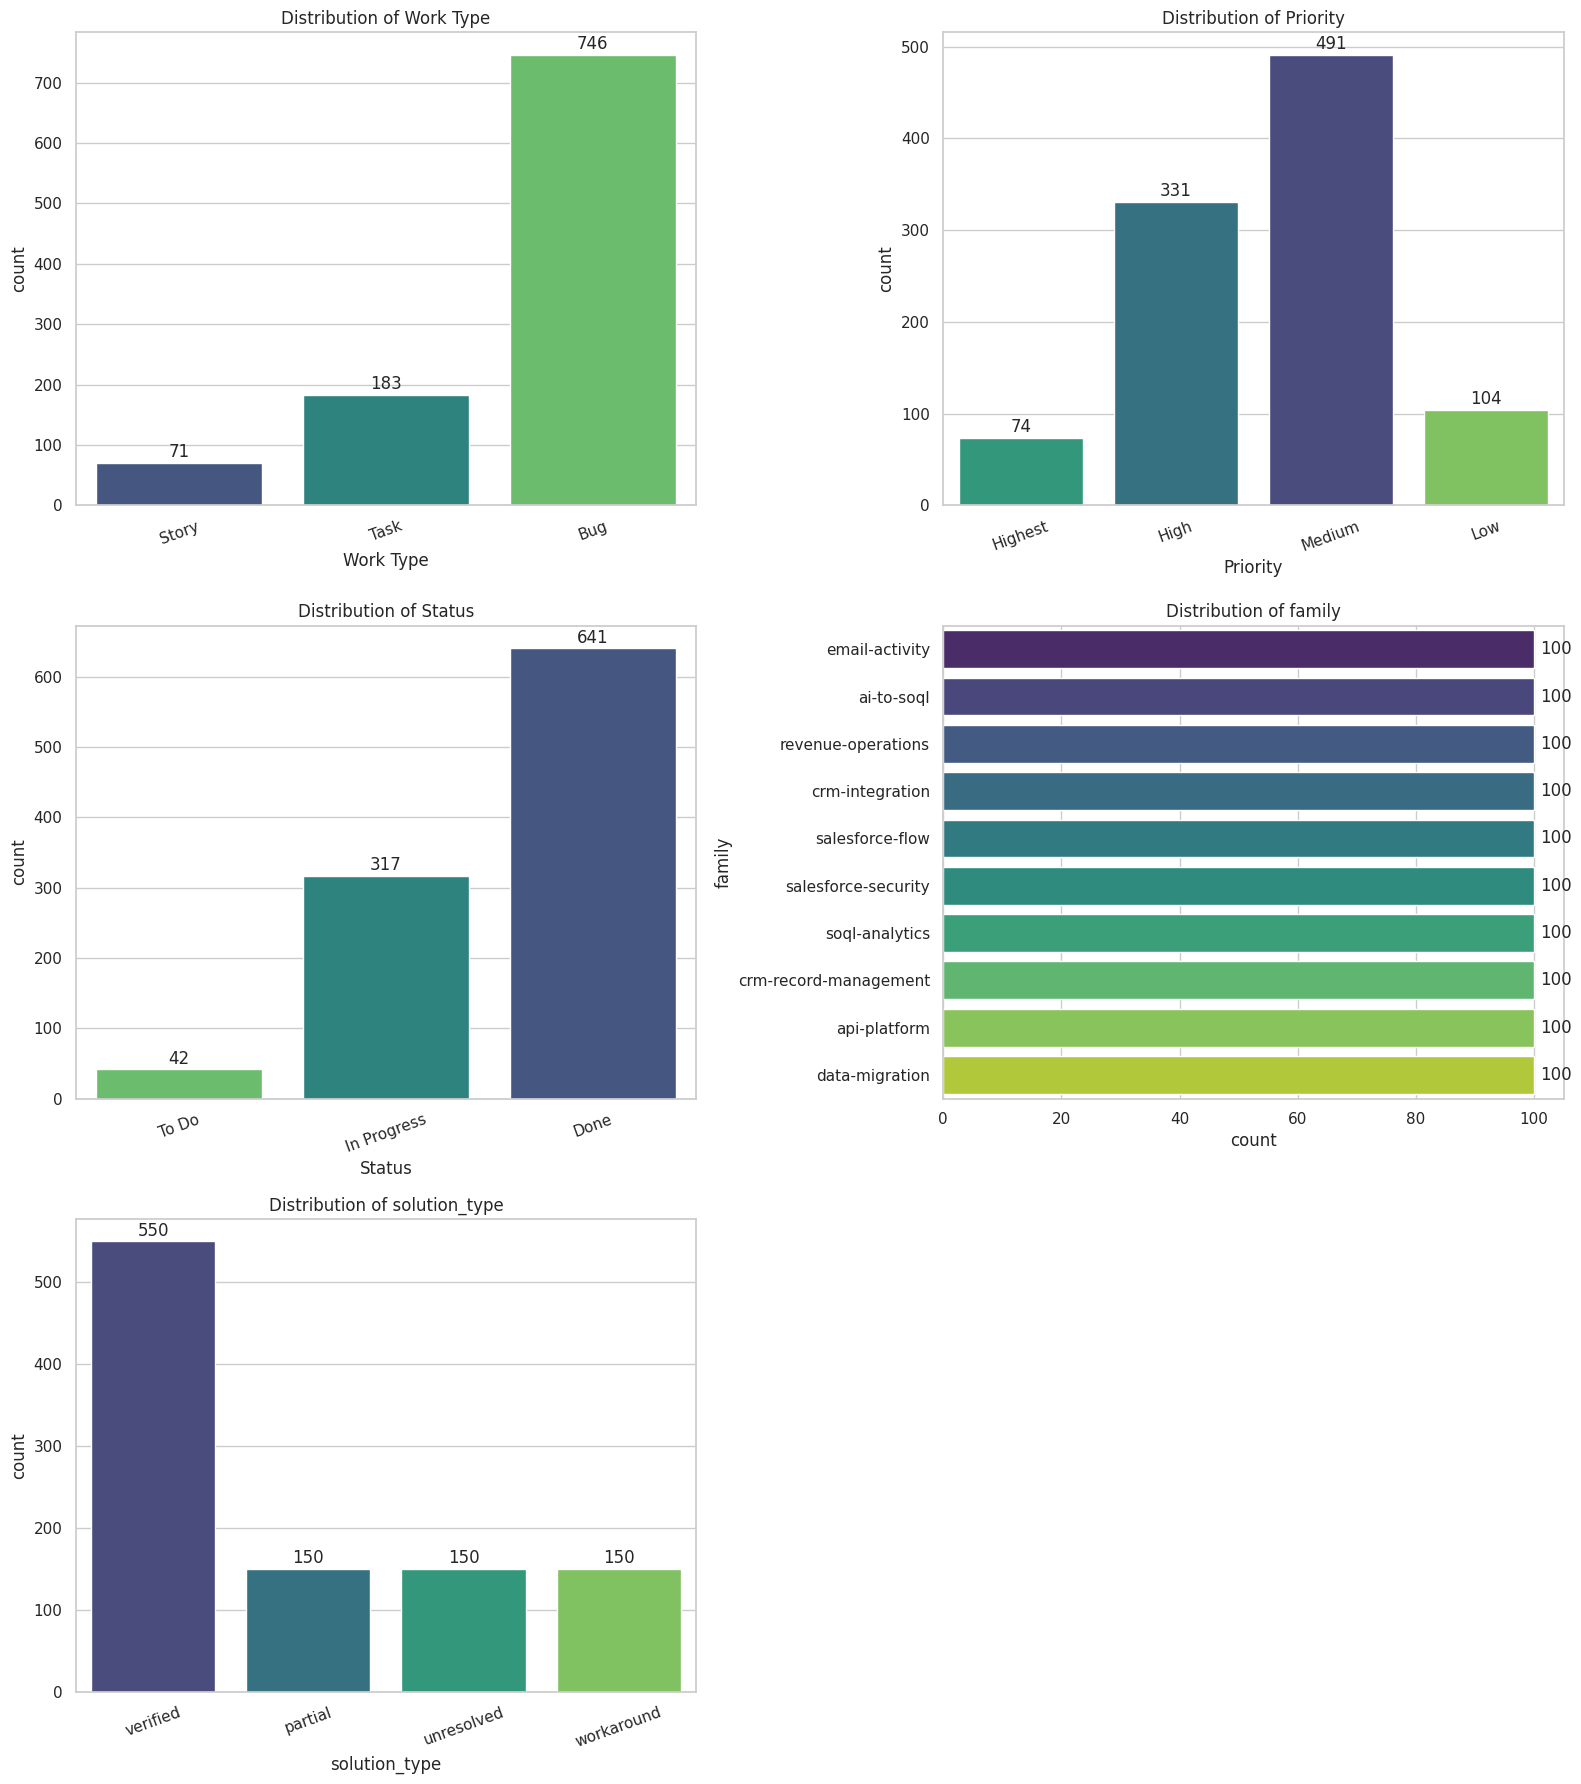

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

eda_df = tickets_df.copy()
ORIGINAL_TICKETS_SCHEMA = tuple(EXPECTED_NORMALIZED_COLUMNS)
EDA_VERSION = "1.1"

CATEGORICAL_FIGURE_PATH = PATHS["reports_figs"] / "eda_categorical_distributions_final_1000_v1.png"
HEATMAP_FIGURE_PATH = PATHS["reports_figs"] / "eda_family_solution_heatmap_final_1000_v1.png"
TEXT_LENGTH_FIGURE_PATH = PATHS["reports_figs"] / "eda_text_lengths_final_1000_v1.png"
EDA_SUMMARY_PATH = PATHS["reports_qa"] / "eda_summary_final_1000_v1.json"

sns.set_theme(style="whitegrid")

overview = {
    "tickets": int(len(eda_df)),
    "families": int(eda_df["family"].nunique()),
    "solution_types": int(eda_df["solution_type"].nunique()),
    "unique_components": int(eda_df["Component"].nunique()),
    "unique_summaries": int(eda_df["Summary"].nunique()),
    "unique_descriptions": int(eda_df["Description"].nunique()),
    "minimum_ticket_id": eda_df["ticket_id"].min(),
    "maximum_ticket_id": eda_df["ticket_id"].max(),
}

print("--- Dataset Overview ---")
display(pd.DataFrame([overview]))

plot_specs = [
    ("Work Type", None, False),
    ("Priority", ["Highest", "High", "Medium", "Low"], False),
    ("Status", ["To Do", "In Progress", "Done"], False),
    ("family", None, True),
    ("solution_type", None, False),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for ax, (column, order, horizontal) in zip(axes, plot_specs):
    plot_df = eda_df[[column]].copy()
    if column == "family":
        plot_df[column] = plot_df[column].str.removeprefix("family-")
    elif column == "solution_type":
        plot_df[column] = plot_df[column].str.removeprefix("solution-")

    if horizontal:
        sns.countplot(data=plot_df, y=column, hue=column, order=order,
                      palette="viridis", legend=False, ax=ax)
        for patch in ax.patches:
            ax.annotate(
                f"{int(patch.get_width())}",
                (patch.get_width(), patch.get_y() + patch.get_height() / 2),
                xytext=(4, 0), textcoords="offset points", va="center"
            )
    else:
        sns.countplot(data=plot_df, x=column, hue=column, order=order,
                      palette="viridis", legend=False, ax=ax)
        ax.tick_params(axis="x", rotation=20)
        for patch in ax.patches:
            ax.annotate(
                f"{int(patch.get_height())}",
                (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                xytext=(0, 4), textcoords="offset points", ha="center"
            )

    ax.set_title(f"Distribution of {column}")

fig.delaxes(axes[-1])
fig.tight_layout()
fig.savefig(CATEGORICAL_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



### 2.2 Family and Solution Coverage

Every family contains exactly 100 tickets. Solution proportions vary slightly between families, but every `family × solution_type` stratum has enough examples to support the planned deterministic 75/15/10 split.


solution_type,solution-partial,solution-unresolved,solution-verified,solution-workaround
family,,,,
family-ai-to-soql,17,15,52,16
family-api-platform,16,14,56,14
family-crm-integration,14,15,56,15
family-crm-record-management,10,15,56,19
family-data-migration,14,16,59,11
family-email-activity,18,14,53,15
family-revenue-operations,15,17,54,14
family-salesforce-flow,16,15,53,16
family-salesforce-security,12,19,52,17


Minimum stratum size: 10
Maximum stratum size: 59


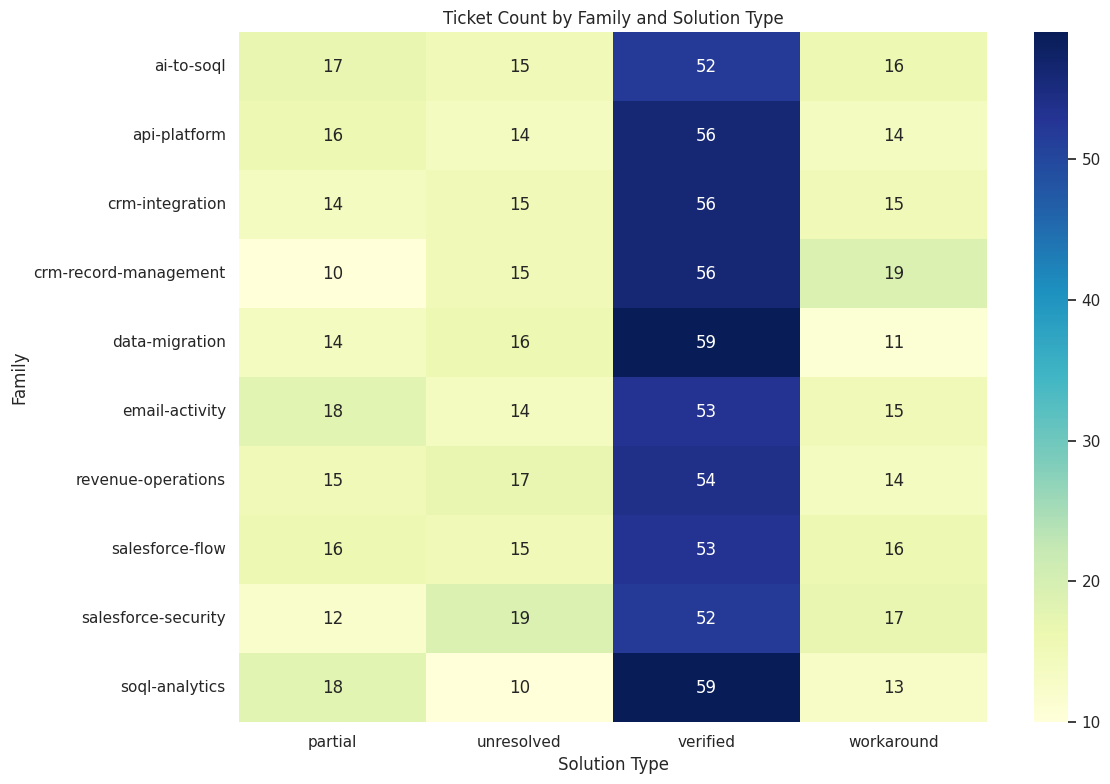

In [20]:

family_solution_counts = pd.crosstab(
    eda_df["family"],
    eda_df["solution_type"]
).sort_index()

display(family_solution_counts)
print(f"Minimum stratum size: {int(family_solution_counts.min().min())}")
print(f"Maximum stratum size: {int(family_solution_counts.max().max())}")

heatmap_display = family_solution_counts.copy()
heatmap_display.index = heatmap_display.index.str.removeprefix("family-")
heatmap_display.columns = heatmap_display.columns.str.removeprefix("solution-")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_display, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Ticket Count by Family and Solution Type")
ax.set_xlabel("Solution Type")
ax.set_ylabel("Family")
fig.tight_layout()
fig.savefig(HEATMAP_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



### 2.3 Text Lengths, Component Cardinality, and Representative Tickets

Text lengths inform the initial chunking decision. `Component` is inspected as metadata rather than as a stratification category because it is almost unique per ticket. Three deterministic examples provide a human-readable sanity check.


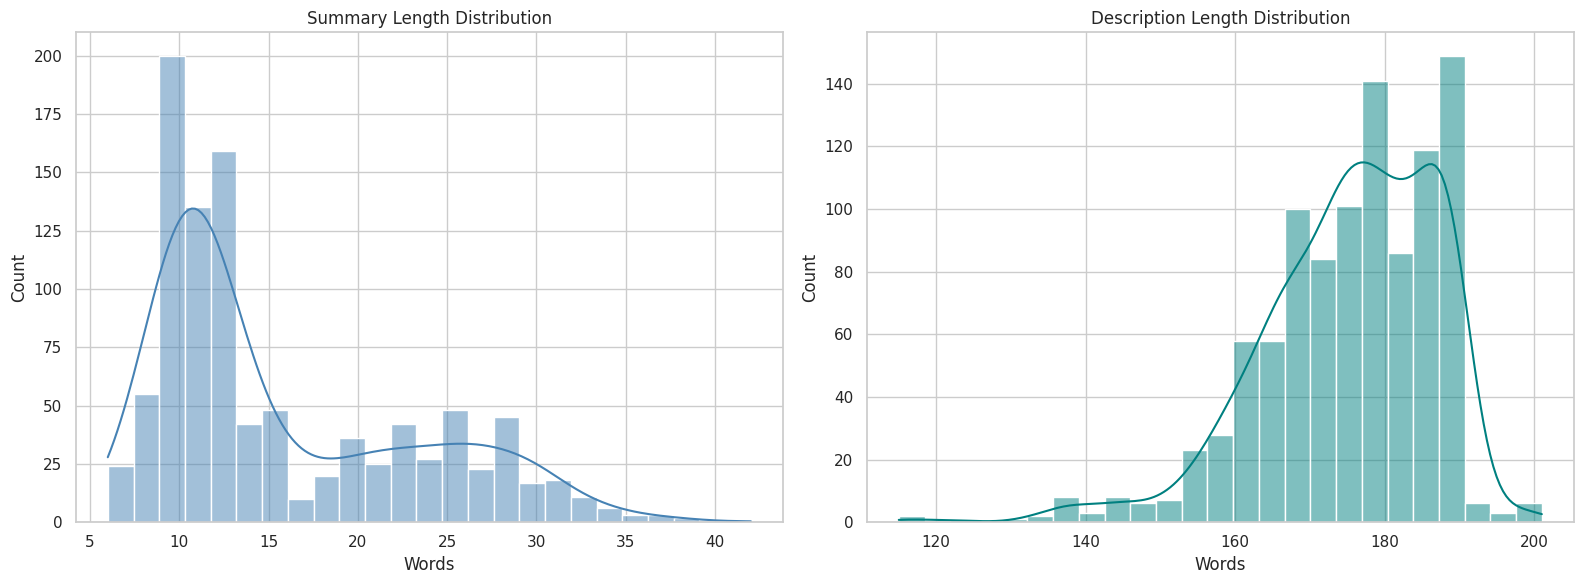

,Summary,Description
count,1000.000000,1000.000000
mean,15.757000,175.297000
std,7.409916,11.779369
min,6.000000,115.000000
25%,10.000000,168.000000
50%,12.000000,177.000000
75%,21.000000,185.000000
max,42.000000,201.000000


Component cardinality: 998 unique values
Repeated Components: {'Delivery Confirmation Gap': 2, 'Negation Handling': 2}
--- Deterministic Representative Tickets ---


,ticket_id,family,solution_type,Status,Priority,Summary,Issue excerpt,Resolution excerpt
0,tckt-0001,family-email-activity,solution-verified,Done,Medium,Latest email engagement is not classified corr...,Inbound replies logged as Tasks are stamped as...,Separate bulk-safe flows were implemented. Nat...
1,tckt-0010,family-crm-integration,solution-workaround,Done,High,Large order batches exceed integration process...,Peak-day batches exceed the job execution wind...,"As a temporary workaround, the job runs in fou..."
2,tckt-0004,family-crm-integration,solution-unresolved,In Progress,Medium,Account intent pipeline cannot complete its Sa...,"The pipeline needs a destination field, authen...",No verified solution has been implemented. Exi...


In [21]:

eda_df["summary_word_count"] = eda_df["Summary"].astype(str).str.split().str.len()
eda_df["description_word_count"] = eda_df["Description"].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(eda_df["summary_word_count"], bins=25, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Summary Length Distribution")
axes[0].set_xlabel("Words")
sns.histplot(eda_df["description_word_count"], bins=25, kde=True, color="teal", ax=axes[1])
axes[1].set_title("Description Length Distribution")
axes[1].set_xlabel("Words")
fig.tight_layout()
fig.savefig(TEXT_LENGTH_FIGURE_PATH, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

text_length_stats = pd.DataFrame({
    "Summary": eda_df["summary_word_count"].describe(),
    "Description": eda_df["description_word_count"].describe(),
})
display(text_length_stats)

component_counts = eda_df["Component"].value_counts()
duplicated_components = {
    str(component): int(count)
    for component, count in component_counts[component_counts > 1].items()
}
print(f"Component cardinality: {eda_df['Component'].nunique()} unique values")
print(f"Repeated Components: {duplicated_components or 'None'}")

def extract_description_section(description, heading, max_chars=250):
    heading_pattern = "|".join(re.escape(item) for item in REQUIRED_DESC_HEADINGS)
    pattern = rf"(?ms)^{re.escape(heading)}\s*$\n?(.*?)(?=^(?:{heading_pattern})\s*$|\Z)"
    match = re.search(pattern, str(description))
    if not match:
        return "N/A"
    value = " ".join(match.group(1).strip().split())
    return value if len(value) <= max_chars else value[:max_chars].rstrip() + "..."

representative_rows = []
for solution_type in ["solution-verified", "solution-workaround", "solution-unresolved"]:
    ticket = (
        eda_df.loc[eda_df["solution_type"] == solution_type]
        .sort_values("ticket_id")
        .iloc[0]
    )
    representative_rows.append({
        "ticket_id": ticket["ticket_id"],
        "family": ticket["family"],
        "solution_type": ticket["solution_type"],
        "Status": ticket["Status"],
        "Priority": ticket["Priority"],
        "Summary": ticket["Summary"],
        "Issue excerpt": extract_description_section(ticket["Description"], "ISSUE OR REQUEST"),
        "Resolution excerpt": extract_description_section(ticket["Description"], "RESOLUTION"),
    })

print("--- Deterministic Representative Tickets ---")
display(pd.DataFrame(representative_rows))


In [22]:

def value_counts_dict(series):
    return {str(key): int(value) for key, value in series.value_counts().sort_index().items()}

def describe_dict(series):
    return {str(key): float(value) for key, value in series.describe().items()}

eda_summary = {
    "dataset_version": CONFIG["dataset_version"],
    "canonical_sha256": canonical_sha256,
    "eda_version": EDA_VERSION,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "overview": overview,
    "category_distributions": {
        "work_type": value_counts_dict(eda_df["Work Type"]),
        "priority": value_counts_dict(eda_df["Priority"]),
        "status": value_counts_dict(eda_df["Status"]),
        "family": value_counts_dict(eda_df["family"]),
        "solution_type": value_counts_dict(eda_df["solution_type"]),
    },
    "text_length_statistics": {
        "summary_words": describe_dict(eda_df["summary_word_count"]),
        "description_words": describe_dict(eda_df["description_word_count"]),
    },
    "component_cardinality": int(eda_df["Component"].nunique()),
    "duplicated_components": duplicated_components,
    "family_solution_counts": {
        str(family): {str(solution): int(count) for solution, count in row.items()}
        for family, row in family_solution_counts.to_dict(orient="index").items()
    },
    "representative_ticket_ids": [row["ticket_id"] for row in representative_rows],
}

with open(EDA_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(eda_summary, file, indent=2, ensure_ascii=False)

required_eda_artifacts = [
    CATEGORICAL_FIGURE_PATH,
    HEATMAP_FIGURE_PATH,
    TEXT_LENGTH_FIGURE_PATH,
    EDA_SUMMARY_PATH,
]

eda_gate_errors = []
if len(eda_df) != CONFIG["target_clean_tickets"]:
    eda_gate_errors.append(f"Unexpected EDA row count: {len(eda_df)}")
if tuple(tickets_df.columns) != ORIGINAL_TICKETS_SCHEMA:
    eda_gate_errors.append("The normalized tickets_df schema was modified during EDA")
if set(eda_df.columns) - set(tickets_df.columns) != {"summary_word_count", "description_word_count"}:
    eda_gate_errors.append("Unexpected derived EDA columns detected")
for artifact_path in required_eda_artifacts:
    if not artifact_path.exists():
        eda_gate_errors.append(f"Missing EDA artifact: {artifact_path.name}")

if eda_gate_errors:
    raise RuntimeError("EDA completion gate failed:\n- " + "\n- ".join(eda_gate_errors))

save_run_metadata("exploratory_data_analysis", {
    "eda_version": EDA_VERSION,
    "canonical_sha256": canonical_sha256,
    "artifacts": [path.name for path in required_eda_artifacts],
})

print("✅ jiRAG Stage 2 completed: EDA artifacts generated and saved")


[INFO] Metadata logged to run_exploratory_data_analysis_20260830_135115.json
✅ jiRAG Stage 2 completed: EDA artifacts generated and saved



### Stage 2 Summary

- The dataset contains 1,000 unique tickets across 10 equally sized technical families.
- The global solution distribution is 55% verified and 15% for each remaining solution type; proportions vary slightly within individual families.
- Every `family × solution_type` stratum contains at least 10 tickets, supporting the planned stratified split.
- Description lengths are compact and consistent, supporting the initial `one ticket = one document` strategy.
- `Component` is a high-cardinality field and should be retained as context or metadata, not as a primary stratification field.



## 3. Deterministic Dataset Splitting

The validated dataset is frozen into Train (750), Validation (150), and Test (100) subsets. Splitting uses seed 42 and the combined `family + solution_type` stratum. The test set is reserved for final evaluation and must not be used for prompt, retriever, or model tuning.


In [23]:

from sklearn.model_selection import train_test_split

STRATIFICATION_COLUMNS = CONFIG["stratification_columns"]
SPLIT_VERSION = CONFIG["split_version"]
SPLIT_MANIFEST_PATH = PATHS["data_manifests"] / f"split_manifest_{SPLIT_VERSION}.json"
SPLIT_IDS_PATH = PATHS["data_manifests"] / f"split_ids_{SPLIT_VERSION}.json"

if not np.isclose(
    CONFIG["train_ratio"] + CONFIG["validation_ratio"] + CONFIG["test_ratio"],
    1.0
):
    raise ValueError("Train, validation, and test ratios must sum to 1.0")

split_source_df = tickets_df.copy()
split_source_df["strat_key"] = (
    split_source_df[STRATIFICATION_COLUMNS[0]].astype(str)
    + "|"
    + split_source_df[STRATIFICATION_COLUMNS[1]].astype(str)
)

train_work_df, remaining_work_df = train_test_split(
    split_source_df,
    train_size=CONFIG["train_ratio"],
    random_state=CONFIG["random_seed"],
    stratify=split_source_df["strat_key"],
)

validation_share_of_remaining = (
    CONFIG["validation_ratio"]
    / (CONFIG["validation_ratio"] + CONFIG["test_ratio"])
)

validation_work_df, test_work_df = train_test_split(
    remaining_work_df,
    train_size=validation_share_of_remaining,
    random_state=CONFIG["random_seed"],
    stratify=remaining_work_df["strat_key"],
)

def finalize_split(work_df):
    return (
        work_df.drop(columns="strat_key")
        .sort_values("ticket_id")
        .reset_index(drop=True)
    )

train_df = finalize_split(train_work_df)
validation_df = finalize_split(validation_work_df)
test_df = finalize_split(test_work_df)

split_frames = {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}

split_paths = {
    name: PATHS["data_splits"] / f"{name}_{SPLIT_VERSION}.csv"
    for name in split_frames
}


In [24]:

expected_split_sizes = {"train": 750, "validation": 150, "test": 100}
source_ids = set(tickets_df["ticket_id"])
split_id_sets = {
    name: set(frame["ticket_id"])
    for name, frame in split_frames.items()
}
expected_strata = set(
    tickets_df["family"].astype(str) + "|" + tickets_df["solution_type"].astype(str)
)

split_errors = []

for name, frame in split_frames.items():
    if len(frame) != expected_split_sizes[name]:
        split_errors.append(f"{name}: expected {expected_split_sizes[name]} rows, found {len(frame)}")
    if tuple(frame.columns) != ORIGINAL_TICKETS_SCHEMA:
        split_errors.append(f"{name}: schema differs from normalized source schema")
    if not frame["ticket_id"].is_unique:
        split_errors.append(f"{name}: duplicate ticket IDs detected")

    observed_strata = set(frame["family"].astype(str) + "|" + frame["solution_type"].astype(str))
    if observed_strata != expected_strata:
        split_errors.append(f"{name}: not all expected family/solution strata are represented")

if split_id_sets["train"] & split_id_sets["validation"]:
    split_errors.append("Train and validation IDs overlap")
if split_id_sets["train"] & split_id_sets["test"]:
    split_errors.append("Train and test IDs overlap")
if split_id_sets["validation"] & split_id_sets["test"]:
    split_errors.append("Validation and test IDs overlap")

combined_split_ids = set().union(*split_id_sets.values())
if combined_split_ids != source_ids:
    split_errors.append("The union of split IDs does not exactly match the source dataset")

source_distributions = {
    column: tickets_df[column].value_counts(normalize=True).sort_index()
    for column in STRATIFICATION_COLUMNS
}
maximum_distribution_deviation = {}
for name, frame in split_frames.items():
    maximum_distribution_deviation[name] = {}
    for column in STRATIFICATION_COLUMNS:
        split_distribution = frame[column].value_counts(normalize=True).sort_index()
        deviation = float((split_distribution - source_distributions[column]).abs().max())
        maximum_distribution_deviation[name][column] = deviation
        if deviation > 0.05:
            split_errors.append(f"{name}: {column} distribution deviation exceeds 5%")

if split_errors:
    raise RuntimeError("Split validation failed:\n- " + "\n- ".join(split_errors))

for name, frame in split_frames.items():
    frame.to_csv(split_paths[name], index=False, encoding="utf-8")

split_ids = {
    "split_version": SPLIT_VERSION,
    "random_seed": CONFIG["random_seed"],
    "source_canonical_sha256": canonical_sha256,
    "ids": {
        name: frame["ticket_id"].tolist()
        for name, frame in split_frames.items()
    },
}
with open(SPLIT_IDS_PATH, "w", encoding="utf-8") as file:
    json.dump(split_ids, file, indent=2, ensure_ascii=False)

# Reload persisted files so validation covers the actual saved artifacts.
for name, path in split_paths.items():
    reloaded = pd.read_csv(path, encoding="utf-8")
    if tuple(reloaded.columns) != ORIGINAL_TICKETS_SCHEMA:
        raise RuntimeError(f"{name}: persisted split schema mismatch")
    if reloaded["ticket_id"].tolist() != split_frames[name]["ticket_id"].tolist():
        raise RuntimeError(f"{name}: persisted split IDs differ from in-memory split")

split_manifest = {
    "split_version": SPLIT_VERSION,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": CONFIG["random_seed"],
    "source_dataset_version": CONFIG["dataset_version"],
    "source_canonical_sha256": canonical_sha256,
    "ratios": {
        "train": CONFIG["train_ratio"],
        "validation": CONFIG["validation_ratio"],
        "test": CONFIG["test_ratio"],
    },
    "stratification_columns": STRATIFICATION_COLUMNS,
    "counts": {name: int(len(frame)) for name, frame in split_frames.items()},
    "unique_strata": {name: 40 for name in split_frames},
    "maximum_distribution_deviation": maximum_distribution_deviation,
    "files": {
        name: {
            "filename": path.name,
            "sha256": calculate_sha256(path),
        }
        for name, path in split_paths.items()
    },
    "split_ids_file": {
        "filename": SPLIT_IDS_PATH.name,
        "sha256": calculate_sha256(SPLIT_IDS_PATH),
    },
    "integrity": {
        "pairwise_disjoint": True,
        "complete_source_coverage": True,
        "all_strata_present_in_every_split": True,
    },
}

with open(SPLIT_MANIFEST_PATH, "w", encoding="utf-8") as file:
    json.dump(split_manifest, file, indent=2, ensure_ascii=False)

split_summary = pd.DataFrame([
    {
        "Split": name.title(),
        "Rows": len(frame),
        "Families": frame["family"].nunique(),
        "Solution types": frame["solution_type"].nunique(),
        "Family × solution strata": (
            frame["family"].astype(str) + "|" + frame["solution_type"].astype(str)
        ).nunique(),
    }
    for name, frame in split_frames.items()
])
display(split_summary)

save_run_metadata("dataset_splitting", {
    "split_version": SPLIT_VERSION,
    "source_canonical_sha256": canonical_sha256,
    "manifest": SPLIT_MANIFEST_PATH.name,
})

print("✅ jiRAG Stage 3 completed: deterministic splits validated and frozen")


,Split,Rows,Families,Solution types,Family × solution strata
0,Train,750,10,4,40
1,Validation,150,10,4,40
2,Test,100,10,4,40


[INFO] Metadata logged to run_dataset_splitting_20260830_135117.json
✅ jiRAG Stage 3 completed: deterministic splits validated and frozen



### 3.1 Dynamically Verified Split Distributions

The stratification key combines `family + solution_type`. With 10 families and 4 solution types, the expected design contains 40 possible strata.

The following code calculates every table directly from the in-memory full dataset and the three validated split DataFrames. No distribution count or percentage is hard-coded in the explanation. Assertions verify that every table sums back to the corresponding dataset before results are displayed or saved.


In [25]:

# Build one source-of-truth mapping for all dynamic split tables.
distribution_frames = {
    "Full Dataset": tickets_df,
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}

def combined_stratification_key(frame):
    return (
        frame[CONFIG["stratification_columns"][0]].astype(str)
        + "|"
        + frame[CONFIG["stratification_columns"][1]].astype(str)
    )

# 1. Overall coverage table, calculated from every DataFrame.
split_overview_table = pd.DataFrame([
    {
        "Split": name,
        "Tickets": int(len(frame)),
        "Families": int(frame["family"].nunique()),
        "Solution Types": int(frame["solution_type"].nunique()),
        "Family × Solution Strata": int(combined_stratification_key(frame).nunique()),
    }
    for name, frame in distribution_frames.items()
])

# 2. Exact solution-type counts.
solution_order = [
    "solution-verified",
    "solution-partial",
    "solution-workaround",
    "solution-unresolved",
]
solution_count_table = pd.DataFrame({
    name: frame["solution_type"].value_counts().reindex(solution_order, fill_value=0).astype(int)
    for name, frame in distribution_frames.items()
})
solution_count_table.index = solution_count_table.index.str.removeprefix("solution-")
solution_count_table.index.name = "Solution Type"

# 3. Percentages are derived from the calculated counts, not typed manually.
solution_percentage_table = solution_count_table.div(
    pd.Series({name: len(frame) for name, frame in distribution_frames.items()}),
    axis="columns",
).mul(100).round(1)

# 4. Exact family counts.
family_order = sorted(tickets_df["family"].unique())
family_distribution_table = pd.DataFrame({
    name: frame["family"].value_counts().reindex(family_order, fill_value=0).astype(int)
    for name, frame in distribution_frames.items()
})
family_distribution_table.index = family_distribution_table.index.str.removeprefix("family-")
family_distribution_table.index.name = "Family"

# 5. Exact allocation of every family × solution_type stratum.
def calculate_stratum_counts(frame):
    return frame.groupby(["family", "solution_type"]).size().rename("count")

strata_distribution_table = pd.concat(
    {
        name: calculate_stratum_counts(frame)
        for name, frame in distribution_frames.items()
    },
    axis="columns",
).fillna(0).astype(int)
strata_distribution_table.columns = strata_distribution_table.columns.get_level_values(0)
strata_distribution_table = strata_distribution_table.reset_index()
strata_distribution_table["family"] = strata_distribution_table["family"].str.removeprefix("family-")
strata_distribution_table["solution_type"] = strata_distribution_table["solution_type"].str.removeprefix("solution-")
strata_distribution_table = strata_distribution_table.rename(columns={
    "family": "Family",
    "solution_type": "Solution Type",
})

# 6. Integrity assertions: every calculated table must sum to its source DataFrame.
expected_sizes = {name: len(frame) for name, frame in distribution_frames.items()}

for name, expected_size in expected_sizes.items():
    assert int(solution_count_table[name].sum()) == expected_size, (
        f"Solution table does not sum to {name} size"
    )
    assert int(family_distribution_table[name].sum()) == expected_size, (
        f"Family table does not sum to {name} size"
    )
    assert int(strata_distribution_table[name].sum()) == expected_size, (
        f"Strata table does not sum to {name} size"
    )

assert split_overview_table.set_index("Split")["Tickets"].to_dict() == expected_sizes
assert (solution_percentage_table.sum(axis=0).sub(100).abs() <= 0.2).all()

# 7. Display all calculated results.
print("--- Split Overview: Calculated Directly from the DataFrames ---")
display(split_overview_table)

print("--- Solution-Type Counts ---")
display(solution_count_table)

print("--- Solution-Type Percentages Within Each Split ---")
solution_percentage_display = solution_percentage_table.map(lambda value: f"{value:.1f}%")
display(solution_percentage_display)

print("--- Family Counts ---")
display(family_distribution_table)

print("--- All Family × Solution-Type Strata ---")
display(strata_distribution_table)

# 8. Select and display one stratum example dynamically.
preferred_example = strata_distribution_table.loc[
    (strata_distribution_table["Family"] == "email-activity")
    & (strata_distribution_table["Solution Type"] == "verified")
]
example_row = (
    preferred_example.iloc[[0]]
    if not preferred_example.empty
    else strata_distribution_table.iloc[[0]]
)

print("--- One Dynamically Retrieved Stratum Example ---")
display(example_row)

# 9. Calculate compact diagnostics for the written interpretation.
family_target = {
    "Train": CONFIG["train_ratio"],
    "Validation": CONFIG["validation_ratio"],
    "Test": CONFIG["test_ratio"],
}
maximum_family_allocation_deviation = {
    split_name: float(
        (
            family_distribution_table[split_name]
            / family_distribution_table["Full Dataset"]
            - target_ratio
        ).abs().max()
    )
    for split_name, target_ratio in family_target.items()
}

print("--- Computed Interpretation ---")
print(
    f"All splits contain {split_overview_table['Families'].min()} families, "
    f"{split_overview_table['Solution Types'].min()} solution types, and "
    f"{split_overview_table['Family × Solution Strata'].min()} combined strata."
)
print(
    "Maximum family-allocation deviation from the requested split ratios: "
    + ", ".join(
        f"{name}={deviation:.1%}"
        for name, deviation in maximum_family_allocation_deviation.items()
    )
)
print(
    "Priority, Status, and Work Type are not part of the stratification key; "
    "adding them would fragment the dataset into many sparse combinations."
)

# 10. Save the dynamically calculated tables for reports and later verification.
dynamic_table_paths = {
    "overview": PATHS["reports_qa"] / f"split_overview_{SPLIT_VERSION}.csv",
    "solution_counts": PATHS["reports_qa"] / f"split_solution_counts_{SPLIT_VERSION}.csv",
    "solution_percentages": PATHS["reports_qa"] / f"split_solution_percentages_{SPLIT_VERSION}.csv",
    "family_counts": PATHS["reports_qa"] / f"split_family_counts_{SPLIT_VERSION}.csv",
    "strata_counts": PATHS["reports_qa"] / f"split_strata_counts_{SPLIT_VERSION}.csv",
}

split_overview_table.to_csv(dynamic_table_paths["overview"], index=False, encoding="utf-8")
solution_count_table.to_csv(dynamic_table_paths["solution_counts"], encoding="utf-8")
solution_percentage_table.to_csv(dynamic_table_paths["solution_percentages"], encoding="utf-8")
family_distribution_table.to_csv(dynamic_table_paths["family_counts"], encoding="utf-8")
strata_distribution_table.to_csv(dynamic_table_paths["strata_counts"], index=False, encoding="utf-8")

assert all(path.exists() for path in dynamic_table_paths.values())
print("✅ Split distribution tables calculated, validated, displayed, and saved")


--- Split Overview: Calculated Directly from the DataFrames ---


,Split,Tickets,Families,Solution Types,Family × Solution Strata
0,Full Dataset,1000,10,4,40
1,Train,750,10,4,40
2,Validation,150,10,4,40
3,Test,100,10,4,40


--- Solution-Type Counts ---


,Full Dataset,Train,Validation,Test
Solution Type,,,,
verified,550,413,85,52
partial,150,112,22,16
workaround,150,112,23,15
unresolved,150,113,20,17


--- Solution-Type Percentages Within Each Split ---


...

--- All Family × Solution-Type Strata ---


,Family,Solution Type,Full Dataset,Train,Validation,Test
0,ai-to-soql,partial,17,13,3,1
1,ai-to-soql,unresolved,15,11,2,2
2,ai-to-soql,verified,52,39,8,5
3,ai-to-soql,workaround,16,12,2,2
4,api-platform,partial,16,12,2,2
5,api-platform,unresolved,14,11,2,1
6,api-platform,verified,56,42,9,5
7,api-platform,workaround,14,11,2,1
8,crm-integration,partial,14,11,2,1
9,crm-integration,unresolved,15,11,2,2


--- One Dynamically Retrieved Stratum Example ---


,Family,Solution Type,Full Dataset,Train,Validation,Test
22,email-activity,verified,53,40,8,5


--- Computed Interpretation ---
All splits contain 10 families, 4 solution types, and 40 combined strata.
Maximum family-allocation deviation from the requested split ratios: Train=1.0%, Validation=1.0%, Test=1.0%
Priority, Status, and Work Type are not part of the stratification key; adding them would fragment the dataset into many sparse combinations.
✅ Split distribution tables calculated, validated, displayed, and saved



The tables above are executable evidence of the split composition. Their values are calculated from the current DataFrames on every run, checked against the source sizes, and saved as report artifacts. No ticket count or percentage in this subsection depends on manually entered results.



### Stage 3 Summary

- The 1,000 tickets are split deterministically into 750 Train, 150 Validation, and 100 Test records.
- Stratification uses the combined `family + solution_type` key with seed 42.
- The three ID sets are pairwise disjoint and together cover the complete source dataset.
- Every split contains all 40 family/solution strata.
- Split files, their SHA-256 fingerprints, frozen ID lists, and a versioned manifest are saved to Drive.
- The Test split is now frozen and reserved for final evaluation.


## 4. RAG Document Preparation

This stage transforms each validated ticket from the Train, Validation, and Test splits into a standardized RAG document format. Each ticket is represented by a single document to maintain 1:1 mapping for citation and traceability.

### Architectural Design
- **`document_id`**: The canonical lookup key using the normalized ticket ID.
- **`search`**: Contains `embedding_text` (Summary, Component, and Description). This is the only field intended for vectorization.
- **`content`**: Preserves raw text for citation and dynamic generation context. Retrieval will use the `document_id` for direct lookup here.
- **`metadata`**: Operational fields (Work Type, Status, Priority) to support future Hybrid Retrieval (metadata filtering + semantic search).
- **`evaluation`**: Protected gold labels (Family, Solution Type). These are strictly excluded from the search index to prevent label leakage.
- **`system`**: Versioning and split identifiers for full artifact traceability.

This stage implements a **Build Once, Load Thereafter** strategy. Artifacts are only rebuilt if `force_rebuild_rag_docs` is enabled or if existing artifacts fail integrity validation.


In [48]:
# 4.1 Configuration and Paths
CONFIG.update({
    "rag_doc_version": "rag_documents_v1",
    "force_rebuild_rag_docs": False  # Final committed value must be False
})

RAG_DOC_ROOT = PATHS["data_processed"] / CONFIG["rag_doc_version"]
RAG_DOC_ROOT.mkdir(parents=True, exist_ok=True)
STAGING_ROOT = RAG_DOC_ROOT / "staging"

DOC_PATHS = {
    name: RAG_DOC_ROOT / f"rag_documents_{name}_v1.jsonl"
    for name in ["train", "validation", "test"]
}
DOC_MANIFEST_PATH = RAG_DOC_ROOT / "rag_documents_manifest_v1.json"

EMBEDDING_TEMPLATE = """Summary: {summary}
Component: {component}
Description: {description}"""

# Schema and Validation Constants
REQUIRED_NESTED_SCHEMA = {
    "search": ["embedding_text"],
    "content": ["summary", "component", "description"],
    "metadata": ["component", "status", "priority", "work_type"],
    "evaluation": ["family", "solution_type"],
    "system": ["split", "document_version"]
}

REQUIRED_SEARCH_LABELS = ["Summary:", "Component:", "Description:"]
FORBIDDEN_SEARCH_LABELS = ["Ticket ID:", "Status:", "Priority:", "Work Type:", "Family:", "Solution Type:", "Split:"]

In [49]:
# 4.2 Document Building and Persistence

def build_embedding_text_from_content(content_dict):
    """Deterministically constructs search text from content only."""
    # Verify no non-content keys are used
    safe_content = {
        "summary": content_dict["summary"],
        "component": content_dict["component"],
        "description": content_dict["description"]
    }
    return EMBEDDING_TEMPLATE.format(**safe_content)

def build_rag_document(row, split_name):
    """Maps a DataFrame row to the standardized RAG JSON schema."""
    content = {
        "summary": str(row['Summary']).strip(),
        "component": str(row['Component']).strip(),
        "description": str(row['Description']).strip()
    }
    return {
        "document_id": str(row['ticket_id']).strip(),
        "search": {
            "embedding_text": build_embedding_text_from_content(content)
        },
        "content": content,
        "metadata": {
            "component": str(row['Component']).strip(),
            "status": str(row['Status']).strip(),
            "priority": str(row['Priority']).strip(),
            "work_type": str(row['Work Type']).strip()
        },
        "evaluation": {
            "family": str(row['family']).strip(),
            "solution_type": str(row['solution_type']).strip()
        },
        "system": {
            "split": split_name,
            "document_version": CONFIG["rag_doc_version"]
        }
    }

def save_jsonl(documents, path):
    with open(path, 'w', encoding='utf-8') as f:
        for doc in documents:
            f.write(json.dumps(doc, ensure_ascii=False) + '\n')

def load_jsonl(path):
    docs = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            docs.append(json.loads(line))
    return docs

In [50]:
# 4.3 Enhanced Validation Suite

def validate_rag_document_strict(doc, split_name):
    """Deep structural, type, and content integrity check."""
    # 1. Top-Level Key Validation
    expected_top_keys = {"document_id", "search", "content", "metadata", "evaluation", "system"}
    actual_top_keys = set(doc.keys())
    if actual_top_keys != expected_top_keys:
        return False, f"Top-level key mismatch. Found: {actual_top_keys}"

    # 2. document_id Validation
    if not isinstance(doc.get("document_id"), str) or not doc["document_id"].strip():
        return False, "Invalid document_id (must be non-empty string)"

    # 3. Nested Schema and Leaf Types
    for block, keys in REQUIRED_NESTED_SCHEMA.items():
        if block not in doc or not isinstance(doc[block], dict):
            return False, f"Missing or invalid block: {block}"
        if set(doc[block].keys()) != set(keys):
            return False, f"Key mismatch in {block}"
        for k in keys:
            val = doc[block][k]
            if not isinstance(val, str) or not val.strip():
                return False, f"Non-string or empty leaf at {block}.{k}"

    # 4. Leakage and Deterministic Build Validation
    for label in FORBIDDEN_SEARCH_LABELS:
        if label in EMBEDDING_TEMPLATE:
            return False, f"Template Violation: Forbidden label {label} in EMBEDDING_TEMPLATE"

    expected_search = build_embedding_text_from_content(doc['content'])
    if doc['search']['embedding_text'] != expected_search:
        return False, "Embedding text mismatch: content not derived deterministically or leakage detected"

    # 5. System Metadata and Versioning
    if doc['system']['split'] != split_name:
        return False, f"Split mismatch: {doc['system']['split']} != {split_name}"
    if doc['system']['document_version'] != CONFIG["rag_doc_version"]:
        return False, f"Document version mismatch: {doc['system']['document_version']} != {CONFIG['rag_doc_version']}"

    return True, ""

def compute_stable_fingerprint(docs):
    serialized = json.dumps(docs, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(serialized.encode('utf-8')).hexdigest()

def check_global_integrity(all_docs_dict, split_frames_dict):
    """Blocking gate for counts, coverage, and overlaps."""
    all_ids = []
    for name, docs in all_docs_dict.items():
        source_df = split_frames_dict[name]
        doc_ids = [d['document_id'] for d in docs]
        source_ids = source_df['ticket_id'].tolist()

        if len(docs) != len(source_df):
            raise RuntimeError(f"{name}: Document count ({len(docs)}) != Source rows ({len(source_df)})")
        if len(set(doc_ids)) != len(doc_ids):
            raise RuntimeError(f"{name}: Duplicate IDs detected")
        if set(doc_ids) != set(source_ids):
            raise RuntimeError(f"{name}: ID coverage mismatch against source split")
        all_ids.extend(doc_ids)

    if len(set(all_ids)) != sum(len(d) for d in all_docs_dict.values()):
        raise RuntimeError("Cross-split ID overlap detected")

In [51]:
# 4.4 Build/Load Orchestrator
import shutil

# 1. Assess Artifact State
expected_files = list(DOC_PATHS.values()) + [DOC_MANIFEST_PATH]
existing_files = [p for p in expected_files if p.exists()]

if not existing_files:
    artifact_state = "none"
elif len(existing_files) == len(expected_files):
    artifact_state = "complete"
else:
    artifact_state = "partial"

all_docs = {}

# 2. Pre-branch Partial State Handling
if artifact_state == "partial" and not CONFIG["force_rebuild_rag_docs"]:
    missing = [p.name for p in (set(expected_files) - set(existing_files))]
    raise RuntimeError(f"Artifact state is partial. Missing files: {missing}. Set force_rebuild_rag_docs=True to rebuild.")

# 3. Handle Build/Load Logic
if CONFIG["force_rebuild_rag_docs"] or artifact_state == "none":
    action = "BUILD"
    print(f"[INFO] Mode: {action}. Starting staged build...")

    # A. Staging Preparation
    if STAGING_ROOT.exists():
        shutil.rmtree(STAGING_ROOT)
    STAGING_ROOT.mkdir(parents=True)

    # B. Build in memory and strictly validate
    in_memory_docs = {name: [build_rag_document(row, name) for _, row in df.iterrows()]
                      for name, df in split_frames.items()}

    # Strict In-Memory Validation
    for name, docs in in_memory_docs.items():
        for doc in docs:
            ok, msg = validate_rag_document_strict(doc, name)
            if not ok: raise RuntimeError(f"In-memory validation failed for {name}: {msg}")
    check_global_integrity(in_memory_docs, split_frames)

    # C. Write to Staging
    staged_paths = {name: STAGING_ROOT / path.name for name, path in DOC_PATHS.items()}
    for name, path in staged_paths.items():
        save_jsonl(in_memory_docs[name], path)

    # D. Staged Reload and Validation
    for name, path in staged_paths.items():
        reloaded = load_jsonl(path)
        if reloaded != in_memory_docs[name]:
            raise RuntimeError(f"Reload equality failure for {name} split in staging")

        # Fingerprint verification against in-memory source
        if compute_stable_fingerprint(reloaded) != compute_stable_fingerprint(in_memory_docs[name]):
            raise RuntimeError(f"Staged fingerprint mismatch for {name}")

        for doc in reloaded:
            ok, msg = validate_rag_document_strict(doc, name)
            if not ok: raise RuntimeError(f"Staged reload validation failed for {name}: {msg}")
        all_docs[name] = reloaded

    check_global_integrity(all_docs, split_frames)

    # E. Manifest Generation
    manifest = {
        "schema_version": "v1.1",
        "document_version": CONFIG["rag_doc_version"],
        "split_version": CONFIG["split_version"],
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "embedding_fields": ["Summary", "Component", "Description"],
        "metadata_fields": REQUIRED_NESTED_SCHEMA["metadata"],
        "evaluation_fields": REQUIRED_NESTED_SCHEMA["evaluation"],
        "counts": {name: len(docs) for name, docs in all_docs.items()},
        "source_fingerprints": split_manifest["files"],
        "output_fingerprints": {name: compute_stable_fingerprint(docs) for name, docs in all_docs.items()}
    }
    staged_manifest_path = STAGING_ROOT / DOC_MANIFEST_PATH.name
    with open(staged_manifest_path, 'w') as f: json.dump(manifest, f, indent=2)

    # F. Atomic Replacement
    for name, path in staged_paths.items():
        path.replace(DOC_PATHS[name])
    staged_manifest_path.replace(DOC_MANIFEST_PATH)
    shutil.rmtree(STAGING_ROOT)

else: # complete
    action = "LOAD"
    print(f"[INFO] Mode: {action}. Validating existing artifacts...")
    with open(DOC_MANIFEST_PATH, 'r') as f: manifest = json.load(f)

    # Comprehensive Manifest Integrity Checks
    if manifest.get("schema_version") != "v1.1": raise RuntimeError("Manifest schema version mismatch")
    if manifest.get("document_version") != CONFIG["rag_doc_version"]: raise RuntimeError("Document version mismatch")
    if manifest.get("split_version") != CONFIG["split_version"]: raise RuntimeError("Split version mismatch")
    if manifest.get("embedding_fields") != ["Summary", "Component", "Description"]: raise RuntimeError("Field definition mismatch")
    if manifest.get("metadata_fields") != REQUIRED_NESTED_SCHEMA["metadata"]: raise RuntimeError("Metadata schema mismatch")
    if manifest.get("evaluation_fields") != REQUIRED_NESTED_SCHEMA["evaluation"]: raise RuntimeError("Evaluation schema mismatch")

    for name, path in DOC_PATHS.items():
        loaded = load_jsonl(path)
        # Verify counts against manifest and current source
        if len(loaded) != manifest["counts"][name]:
            raise RuntimeError(f"Count mismatch: {name} loaded {len(loaded)} != manifest {manifest['counts'][name]}")
        if len(loaded) != len(split_frames[name]):
            raise RuntimeError(f"Count mismatch: {name} loaded {len(loaded)} != current source {len(split_frames[name])}")

        # Verify fingerprints and source matching
        if compute_stable_fingerprint(loaded) != manifest["output_fingerprints"][name]:
            raise RuntimeError(f"Output fingerprint mismatch for {name}")
        if calculate_sha256(split_paths[name]) != manifest["source_fingerprints"][name]["sha256"]:
            raise RuntimeError(f"Source split {name} has changed since RAG build")

        # Deep Document Validation
        for doc in loaded:
            ok, msg = validate_rag_document_strict(doc, name)
            if not ok: raise RuntimeError(f"Integrity failure in {name} split: {msg}")

        all_docs[name] = loaded

    # Final Global Integrity Blocking Gate
    check_global_integrity(all_docs, split_frames)

[INFO] Mode: LOAD. Validating existing artifacts...


In [52]:
# 4.5 Completion Gate

summary_stats = []
for name, docs in all_docs.items():
    source_df = split_frames[name]
    doc_ids = [d['document_id'] for d in docs]

    summary_stats.append({
        "Split": name.title(),
        "Source Rows": len(source_df),
        "Documents": len(docs),
        "Unique IDs": len(set(doc_ids)),
        "Missing Required Fields": "None",
        "ID Coverage": "100%",
        "Validation": "✅ Passed",
        "Source Fingerprint": manifest["source_fingerprints"][name]["sha256"][:10],
        "Output Fingerprint": manifest["output_fingerprints"][name][:10]
    })

display(pd.DataFrame(summary_stats))

# All validation logic is now moved to the blocking orchestrator.
# If we reached this point, all checks passed.
print(f"\n✅ Existing RAG document artifacts validated and loaded" if action == "LOAD"
      else f"\n✅ RAG document artifacts built and saved")

print("--- Sample Document Structure (Validation Split) ---")
display(all_docs['validation'][0])

,Split,Source Rows,Documents,Unique IDs,Missing Required Fields,ID Coverage,Validation,Source Fingerprint,Output Fingerprint
0,Train,750,750,750,None,100%,✅ Passed,369c3d45c1,0efdfbf714
1,Validation,150,150,150,None,100%,✅ Passed,767e663b85,563e886fa9
2,Test,100,100,100,None,100%,✅ Passed,a6fedf5d33,d4c936138f



✅ Existing RAG document artifacts validated and loaded
--- Sample Document Structure (Validation Split) ---


{'document_id': 'tckt-0007',
 'search': {'embedding_text': 'Summary: Scheduled renewal actions intermittently remain pending\nComponent: Renewal Scheduling\nDescription: CONTEXT\nA scheduled flow path sends renewal reminders 30 days before Contract EndDate.\n\nISSUE OR REQUEST\nA small subset of contracts reaches the reminder date without producing an email or a failed-flow record.\n\nEXPECTED BEHAVIOR\nEvery eligible active contract should generate one renewal reminder.\n\nACTUAL BEHAVIOR\nMost reminders are sent, but several scheduled actions remain pending beyond their execution time.\n\nINVESTIGATION AND FINDINGS\nThe affected records have valid email addresses and meet the flow criteria. Pending-interview exports show the actions, but current logs do not include their execution attempt. The root cause has not yet been identified. Current evidence suggests an execution-capacity or scheduling issue, but this is not verified.\n\nRESOLUTION\nNo verified resolution is currently availab